## 22 June 2026
## Sapkas Michail
### Lunar Lander - Final Project for Deep Neural Networks

Implement the Actor-Critic

# Deep Deterministic Policy Gradient (DDPG) algorithm

# Multiple Actors (Not used)

In [ ]:
import torch
import random
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import time
import os

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # For Mac Apple Silicon users
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


In [30]:
CRITIC_LATENT_DIM = ACTOR_LATENT_DIM = 128
LR_CRITIC = LR_ACTOR = 1e-3

BATCH_SIZE = 64

TAU = 0.005

GAMMA = 0.99
MIN_REPLAY_SIZE = 10_000
REPLAY_BUFFER_SIZE = 300_000

TARGET_UPDATE_FREQ = TRAIN_FREQ = 4
# TARGET_UPDATE_FREQ = 10

SIGMA_START = 1.0
SIGMA_DECAY = 0.998
SIGMA_MIN = 0.05

# TOTAL_TIMESTEPS = 300_000

In [31]:
def update_sigma_decay(sigma):
    return max(SIGMA_MIN, sigma * SIGMA_DECAY)

In [32]:
OBSERVATION_SPACE = 8
ACTION_SPACE = 2

class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(OBSERVATION_SPACE, ACTOR_LATENT_DIM),
            nn.ReLU(),
            nn.Linear(ACTOR_LATENT_DIM, ACTOR_LATENT_DIM),
            nn.ReLU(),
            nn.Linear(ACTOR_LATENT_DIM, ACTION_SPACE),
            nn.Tanh()                                        # Actions are in range [-1, 1]
        )
    def forward(self, state):
        return self.network(state)

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(OBSERVATION_SPACE + ACTION_SPACE, CRITIC_LATENT_DIM),
            nn.ReLU(),
            nn.Linear(CRITIC_LATENT_DIM, CRITIC_LATENT_DIM),
            nn.ReLU(),
            nn.Linear(CRITIC_LATENT_DIM, 1),
        )
    def forward(self, state, action):
        combined_features = torch.cat([state, action], dim=1)
        return self.network(combined_features)
    
# Main networks
actor = Actor().to(device)
critic = Critic().to(device)

# Target networks
actor_target = Actor().to(device)
critic_target = Critic().to(device)
actor_target.load_state_dict(actor.state_dict())
critic_target.load_state_dict(critic.state_dict())

# Balanced Learning Rates (Critic learns faster than Actor to provide stable gradients)
actor_optimizer = optim.Adam(actor.parameters(), lr=LR_ACTOR)
critic_optimizer = optim.Adam(critic.parameters(), lr=LR_CRITIC)
loss_fn = nn.MSELoss()

In [33]:
# TRAINING STEP
def train_step():

    mini_batch = random.sample(replay_buffer, BATCH_SIZE)
    states, actions, rewards, next_states, dones = zip(*mini_batch)

    states = torch.FloatTensor(np.array(states)).to(device)
    actions = torch.FloatTensor(np.array(actions)).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    next_states = torch.FloatTensor(np.array(next_states)).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    # Put networks into explicit training mode
    actor.train()
    critic.train()

    # Forward pass on the target networks, no need to keep track of the gradients
    with torch.no_grad():
        next_actions = actor_target(next_states)
        next_q_values = critic_target(next_states, next_actions)
        target_q_values = rewards + (GAMMA * next_q_values * (1 - dones))

    # CRITIC
    current_q_values = critic(states, actions)
    critic_loss = loss_fn(current_q_values, target_q_values)
    
    critic_optimizer.zero_grad()
    critic_loss.backward()
    critic_optimizer.step()

    # ACTOR
    # We predict new actions from the current states to maintain the gradient chain
    predicted_actions = actor(states)
    actor_loss = -critic(states, predicted_actions).mean()  # - sign performs gradient ascent
    
    actor_optimizer.zero_grad()
    actor_loss.backward()
    actor_optimizer.step()

In [34]:
INJECT_PARAM_NOISE_FREQ = 100
N_ACTORS = 4


actors = []

for _ in range(N_ACTORS):
    net = Actor().to(device)
    # Explicitly attach the optimizer to the network object
    net.optimizer = torch.optim.Adam(net.parameters(), lr=1e-4) 
    actors.append(net)

def inject_parameter_noise(actors, noise_scale=0.01):
    """Injects a slight Gaussian noise directly into the parameters of the actors."""
    with torch.no_grad():
        for actor in actors:
            for param in actor.parameters():
                # Generate noise matching the parameter shape
                noise = torch.randn_like(param) * noise_scale
                param.add_(noise)

In [35]:
replay_buffer = deque(maxlen=REPLAY_BUFFER_SIZE)
sigma = SIGMA_START

# STATISTICS TRACKING
episode_rewards = []
episode_lengths = []
moving_avg_rewards = []
current_episode_reward = 0
current_episode_length = 0
prev_avg_reward = None

def mult_actors_train_step():
    mini_batch = random.sample(replay_buffer, BATCH_SIZE)
    states, actions, rewards, next_states, dones = zip(*mini_batch)

    states = torch.FloatTensor(np.array(states)).to(device)
    actions = torch.FloatTensor(np.array(actions)).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    next_states = torch.FloatTensor(np.array(next_states)).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    # 1. Update Critic (Only needs to happen once per batch)
    critic.train()
    with torch.no_grad():
        next_actions = actor_target(next_states)
        next_q_values = critic_target(next_states, next_actions)
        target_q_values = rewards + (GAMMA * next_q_values * (1 - dones))

    current_q_values = critic(states, actions)
    critic_loss = loss_fn(current_q_values, target_q_values)
    
    critic_optimizer.zero_grad()
    critic_loss.backward()
    critic_optimizer.step()

    # 2. Update All Actors and Track Soft Updates
    for individual_actor in actors:
        individual_actor.train()
        predicted_actions = individual_actor(states)
        
        # Critic guides each individual actor to maximize Q-value
        actor_loss = -critic(states, predicted_actions).mean()
        
        # Ensure you attached an optimizer to each actor object during setup!
        individual_actor.optimizer.zero_grad()
        actor_loss.backward()
        individual_actor.optimizer.step()

        # 3. Soft Target Update (Every actor smoothly pulls the target network)
        # We scale TAU by N_ACTORS so the target network doesn't move 4x too fast
        scaled_tau = TAU / len(actors)
        with torch.no_grad():
            for param, target_param in zip(individual_actor.parameters(), actor_target.parameters()):
                target_param.data.copy_(scaled_tau * param.data + (1.0 - scaled_tau) * target_param.data)
                
    # 4. Critic Target Update (Done once per train step)
    with torch.no_grad():
        for param, target_param in zip(critic.parameters(), critic_target.parameters()):
            target_param.data.copy_(TAU * param.data + (1.0 - TAU) * target_param.data)

# ENVIRONMENT LOOP
env = gym.make("LunarLander-v3", continuous=True)
observation, info = env.reset(seed=42)

print("Initializing training loop...", flush=True)
pbar = tqdm(range(TOTAL_TIMESTEPS), desc="Training", leave=True)
pbar.set_postfix({"Ep": 0, "100-Ep Avg": 0.0, "Status": "Warming Up"})

for step in pbar:
    
    if len(replay_buffer) < MIN_REPLAY_SIZE:
        # Warm-up: sample a completely random action
        action_to_step = env.action_space.sample()
    else:
        # Network inference mode for all actors
        state_tensor = torch.FloatTensor(observation).unsqueeze(0).to(device)
        collected_actions = []
        
        for actor in actors:
            actor.eval()
            with torch.no_grad():
                act = actor(state_tensor).squeeze(0).cpu().numpy()
                collected_actions.append(act)
        
        # 1. Average the actions outputted by all actors
        averaged_action = np.mean(collected_actions, axis=0)
        
        # 2. Inject your continuous exploration noise
        action_to_step = averaged_action + np.random.normal(0, sigma, size=2)
        action_to_step = np.clip(action_to_step, -1.0, 1.0)

    # 3. Step the environment ONCE using the unified action
    next_observation, reward, terminated, truncated, info = env.step(action_to_step)
    done = terminated or truncated
        
    current_episode_reward += reward
    current_episode_length += 1

    # Store the collective experience in the replay buffer
    replay_buffer.append((observation, action_to_step, reward, next_observation, done))
    observation = next_observation

    # Train steps
    if len(replay_buffer) >= MIN_REPLAY_SIZE and step % TRAIN_FREQ == 0:
        # Pass your list of actors to your updated training step
        mult_actors_train_step()

    # Inject Parameter Noise
    if step % INJECT_PARAM_NOISE_FREQ == 0:
        inject_parameter_noise(actors, noise_scale=0.01)

    # Handle Episode Termination & Sigma Decay
    if done:
        episode_rewards.append(current_episode_reward)
        episode_lengths.append(current_episode_length)
        avg_reward = np.mean(episode_rewards[-100:])

        if len(replay_buffer) >= MIN_REPLAY_SIZE:
            sigma = update_sigma_decay(sigma, len(replay_buffer), MIN_REPLAY_SIZE)

        pbar.set_postfix({
            "Ep": len(episode_rewards),
            "100-Ep Avg": f"{avg_reward:.1f}",
            "Sigma": f"{sigma:.3f}"
        })

        observation, info = env.reset()
        current_episode_reward = 0
        current_episode_length = 0

env.close()
print("\nTraining Complete!")

Initializing training loop...


Training: 100%|██████████| 300000/300000 [1:42:21<00:00, 48.85it/s, Ep=2229, 100-Ep Avg=-101.1, Sigma=0.000]


Training Complete!


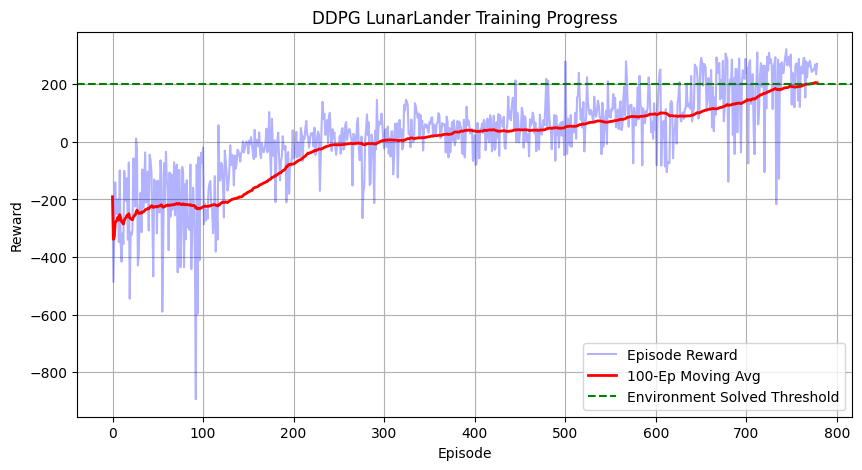

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, color="blue", label="Episode Reward")
plt.plot(moving_avg_rewards, color="red", linewidth=2, label="100-Ep Moving Avg")
plt.axhline(y=200, color="green", linestyle="--", label="Environment Solved Threshold")
plt.title("DDPG LunarLander Training Progress")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.savefig("ddpg_lunar_lander_progress.png")
plt.show()

In [38]:
test_actor = Actor().to(device)
test_actor.load_state_dict(torch.load("ddpg_actor_lunar_lander.pth", map_location=device))
test_actor.eval()  # Set network to evaluation mode (turns off dropout, batchnorm etc.)
 
# Determine the device the actor is currently living on (handles CPU/CUDA automatically)
current_device = next(test_actor.parameters()).device

# Initialize environment in "human" render mode with continuous action space
env = gym.make("LunarLander-v3", continuous=True, render_mode="human")

# Run for 5 demonstration episodes
NUM_EPISODES = 5

for episode in range(NUM_EPISODES):
    observation, info = env.reset()
    episode_reward = 0
    done = False

    print(f"Starting DDPG Evaluation Episode {episode + 1}...")

    while not done:
        # Convert observation to tensor and send it to the actor's current device
        state_tensor = torch.FloatTensor(observation).unsqueeze(0).to(current_device)

        # Pure Exploitation: Get raw continuous control values from the Actor
        with torch.no_grad():
            # squeeze(0).cpu().numpy() handles bringing it back safely to system memory
            action = test_actor(state_tensor).squeeze(0).cpu().numpy()

        # Step the environment with continuous controls
        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        episode_reward += reward

        # Small sleep delay so the human eye can track the smooth engine firing
        time.sleep(0.01)

    print(f"Episode {episode + 1} Finished! Total Reward: {episode_reward:.1f}\n")

env.close()
print("Evaluation Complete!")

Starting DDPG Evaluation Episode 1...
Episode 1 Finished! Total Reward: 263.0

Starting DDPG Evaluation Episode 2...
Episode 2 Finished! Total Reward: 261.7

Starting DDPG Evaluation Episode 3...
Episode 3 Finished! Total Reward: 282.2

Starting DDPG Evaluation Episode 4...
Episode 4 Finished! Total Reward: 251.5

Starting DDPG Evaluation Episode 5...
Episode 5 Finished! Total Reward: 262.0

Evaluation Complete!
